In [ ]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from cartopy.crs import Geodetic, Stereographic, PlateCarree, Orthographic
from cartopy.feature import LAND, COASTLINE

import xarray as xr
from glob import glob
import time
import warnings

import pandas as pd
import geopandas as gpd

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
# Parameters
year = 2024
isPapermill = True
site = 15

dist = 20

In [3]:
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [4]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
trajectory_path = Path(folder_path, f"Trajectories/{year}/")
sample_Points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
out_path = Path(folder_path, f"RadiusConnectivity/")

In [5]:
gdf_sample_points = gpd.read_file(sample_Points_path)
gdf_sample_points.SampleKind.loc[site] = "active"

sample_name = gdf_sample_points.loc[site].SampleID

trajectory_file = sorted(trajectory_path.glob(f"*{sample_name}*"))[0]

# Functions

In [6]:
def connectivity_function(
    ds=None,
    dist=None,
):
    # Mean radius of the Earth in km
    R = 6371  

    # Stations (targets)
    obs_lon_deg = ds.lon
    obs_lat_deg = ds.lat
    obs_lon_km = R * np.cos(np.radians(obs_lat_deg)) * np.radians(obs_lon_deg)
    obs_lat_km = R * np.radians(obs_lat_deg)

    # Particles
    target_lon_deg = xr.DataArray(lons)
    target_lat_deg = xr.DataArray(lats)
    target_lon_km = R * np.cos(np.radians(target_lat_deg)) * np.radians(target_lon_deg)
    target_lat_km = R * np.radians(target_lat_deg)

    # Calculate distance to target
    distance_to_target = (
        ((obs_lon_km - target_lon_km) ** 2) + ((obs_lat_km - target_lat_km) ** 2)
    ) ** 0.5

    # Return number of particles within a certain distance from target
    return (distance_to_target <= dist).sum(dim=["obs", "trajectory"]).compute().values
    # return distance_to_target

In [ ]:
export_vars = ["lat", "lon"]

In [8]:
print("get", year, sample_name)
if isPapermill == False:
    ds_trajectories = (
        xr.open_zarr(trajectory_file)
        .isel(trajectory=slice(None, None, 7000))
        .chunk(chunks={'trajectory':-1,'obs':-1,})
    )
else:
    ds_trajectories = (
        xr.open_zarr(trajectory_file)
        .chunk(chunks={'trajectory':100000,'obs':100,})
    )

get 2024 DB02


In [ ]:
time_mask = ((ds_trajectories.age_sec/(60*60*24)) > 10).compute()
ds_positions = ds_trajectories.get(export_vars).where(time_mask, drop=True)

<xarray.Dataset> Size: 3GB
Dimensions:     (trajectory: 87000, obs: 2049)
Coordinates:
  * obs         (obs) int32 8kB 640 641 642 643 644 ... 2684 2685 2686 2687 2688
  * trajectory  (trajectory) int64 696kB 0 1 2 3 4 ... 86996 86997 86998 86999
Data variables:
    lat         (trajectory, obs) float64 1GB dask.array<chunksize=(87000, 99), meta=np.ndarray>
    lon         (trajectory, obs) float64 1GB dask.array<chunksize=(87000, 99), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_3D_SIGMABSHAgingDeleteErr...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [13]:
df_trajectories = ds_positions.to_dataframe().dropna().reset_index().drop(columns=['obs', 'trajectory'])

In [14]:
gdf_trajectories = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df_trajectories.lon, df_trajectories.lat, crs=Geodetic()))
nrows_half = np.round(len(gdf_trajectories)/2).astype("int")

In [15]:
# Define the the radius of interest around the sample points
centroid = gdf_sample_points.dissolve().centroid.to_crs(Geodetic())
area_of_interest = (
    gpd.GeoDataFrame(
        gdf_sample_points.SampleID,
        geometry=gdf_sample_points.to_crs(
            Orthographic(
                # Set the central position of the Projection to the centroid
                central_longitude=centroid.x.values[0], 
                central_latitude=centroid.y.values[0]
                )
            )
        # Set the Bufferdistance to the given distance in kilometers
        .buffer(distance=dist*1e3)
        # Reproject to the map projection
        .to_crs(Geodetic())
        )
    )

In [ ]:
gdf_joined = (
    gpd.sjoin(
        left_df=gdf_trajectories,
        right_df=area_of_interest,
        how="left",
        rsuffix="polygon",
    )
    .dropna()
    .drop(columns='index_polygon')
    .to_crs(map_projection)
)
gdf_joined

,geometry,SampleID
0,POINT (-497412.127 -239480.202),DB02
1,POINT (-497063.551 -239731.908),DB02
2,POINT (-496490.033 -240173.263),DB02
3,POINT (-496489.954 -240173.324),DB02
4,POINT (-496259.634 -240355.803),DB02
...,...,...
120617955,POINT (-492935.839 -267361.33),DB02
120617956,POINT (-493356.975 -267075.014),DB02
120617957,POINT (-494210.984 -266562.161),DB02
120617958,POINT (-494211.122 -266562.087),DB02


In [23]:
endlocation_count = gdf_joined.SampleID.value_counts()
endlocation_count

SampleID
DB02    27663496
DB01     1211353
SK02         103
Name: count, dtype: int64

In [ ]:
for n in range(10):
    try:
        try:
            connectivity_matrix_total = pd.read_csv(Path(out_path,f"connectivitymatrix_radius_{year}.csv"), index_col=0)
            for endlocation_name, count in endlocation_count.items():
                connectivity_matrix_total.loc[sample_name].loc[endlocation_name] = count
            connectivity_matrix_total.to_csv(Path(out_path, f"connectivitymatrix_radius_{year}.csv"))
            print('Updated file')
        except:
            connectivity_matrix = pd.DataFrame(
                np.zeros([len(gdf_sample_points.SampleID),len(gdf_sample_points.SampleID)]),
                index=gdf_sample_points.SampleID,
                columns=gdf_sample_points.SampleID,
            )
            for endlocation_name, count in endlocation_count.items():
                connectivity_matrix.loc[sample_name].loc[endlocation_name] = count
            connectivity_matrix.to_csv(Path(out_path, f"connectivitymatrix_radius_{year}.csv"))
            print('Made a new file')
        break
    except:
        print('n')
        print(np.random.rand()*n**2)
        time.sleep(np.random.rand()*n**2)

Updated file


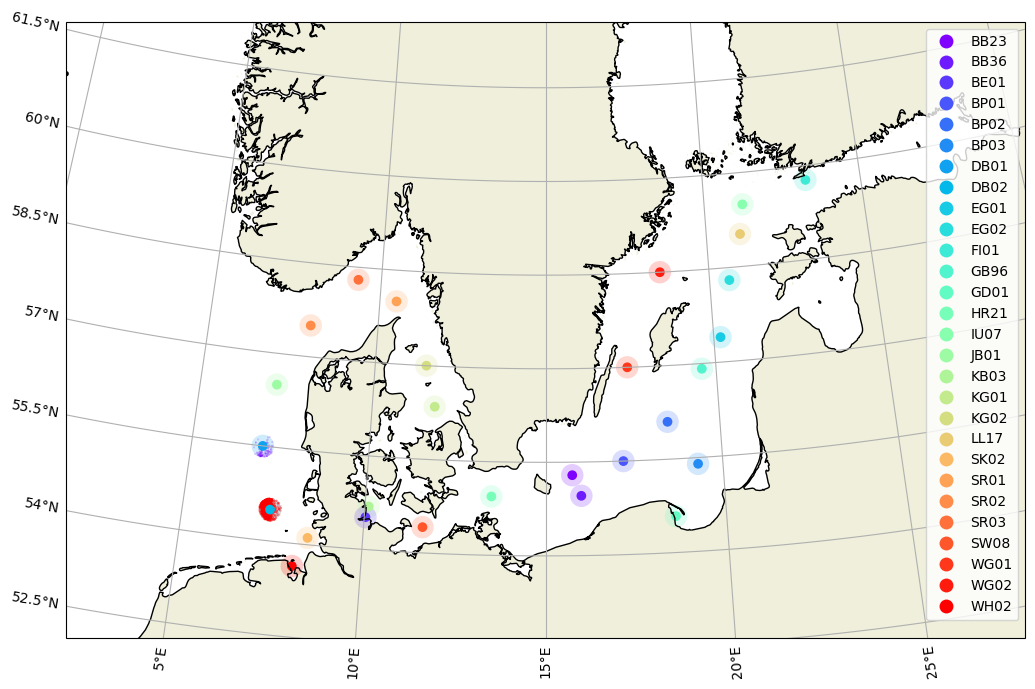

In [32]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
area_of_interest.to_crs(map_projection).plot(ax=ax_map, column="SampleID", alpha=0.2, legend=True, cmap='rainbow')
gdf_joined[::24*400].plot(ax=ax_map, column="SampleID", cmap="rainbow", s=0.01)
gdf_sample_points.plot(ax=ax_map, column="SampleID", legend=True, cmap='rainbow')
plt.show()